# I. Import

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import glob
import re
import os
import random
import warnings
import datetime as dt

import sys
from pathlib import Path 
import cv2
import ast
import getpass
from pydantic import field_validator, Field, BaseModel
from typing import Optional, List , Literal

from groq import Groq

import torch 

In [3]:
def set_seed(SEED: int):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

def get_device():
    device = "cuda" if torch.cuda.is_available is True else "cpu"
    return device

In [4]:
SEED = 2026 
DATA_PATH = "../dataset"
TRAIN_PATH = "train_images"
VAL_PATH = "val_images"

TRAIN_IMAGES_PATH = os.path.join(DATA_PATH, TRAIN_PATH)
VAL_IMAGES_PATH = os.path.join(DATA_PATH, VAL_PATH)
TRAIN_DF_PATH = os.path.join(DATA_PATH, "mcocr_train_df.csv")
VAL_DF_PATH = os.path.join(DATA_PATH,"mcocr_val_sample_df.csv")

In [5]:
set_seed(2026)
print("Devices: " + get_device())
warnings.filterwarnings("ignore")

Devices: cpu


In [6]:
train_imgs = glob.glob(TRAIN_IMAGES_PATH + "/train_images/**.jpg")
test_imgs = glob.glob(VAL_IMAGES_PATH + "/val_images/**.jpg")

print(f"Length of train set: {len(train_imgs)}")
print(f"Length of test set: {len(test_imgs)}")

Length of train set: 1155
Length of test set: 391


In [7]:
def read_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def show_images(images, titles=None, cols=5, figsize=(15, 10)):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
df_train = pd.read_csv(TRAIN_DF_PATH)
df_train.head()

,img_id,anno_polygons,anno_texts,anno_labels,anno_num,anno_image_quality
0,mcocr_public_145013ddcph.jpg,"[{'category_id': 15, 'segmentation': [[231.9, ...",MINIMART ANAN|||Chợ Sủi Phú Thị Gia Lâm|||Ngày...,SELLER|||ADDRESS|||TIMESTAMP|||TOTAL_COST|||TO...,5,0.635309
1,mcocr_public_145013fxcgs.jpg,"[{'category_id': 15, 'segmentation': [[311.6, ...",VinCommerce|||VM + QNH Dự án quỹ đất đường sắt...,SELLER|||ADDRESS|||ADDRESS|||ADDRESS|||TIMESTA...,7,0.774317
2,mcocr_public_145013clltn.jpg,"[{'category_id': 15, 'segmentation': [[626.8, ...",SIEU THI BACH HOA TONG HOP|||Bố 5 Cẩm Tây - Cẩ...,SELLER|||ADDRESS|||TOTAL_COST|||TOTAL_COST|||T...,5,0.664084
3,mcocr_public_145013tmibr.jpg,"[{'category_id': 15, 'segmentation': [[715.5, ...",co.op mart|||Co.opMart HAU GIANG|||188 Hau Gia...,SELLER|||SELLER|||ADDRESS|||ADDRESS|||TIMESTAM...,8,0.715504
4,mcocr_public_145013kgypr.jpg,"[{'category_id': 16, 'segmentation': [[200.5, ...","Tổ 7, Khu Minh Tiến A|||VinCommerce|||Ngày bán...",ADDRESS|||SELLER|||TIMESTAMP|||TOTAL_COST|||TO...,5,0.766884


In [9]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   img_id              1155 non-null   str    
 1   anno_polygons       1155 non-null   str    
 2   anno_texts          1153 non-null   str    
 3   anno_labels         1153 non-null   str    
 4   anno_num            1155 non-null   int64  
 5   anno_image_quality  1155 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 54.3 KB


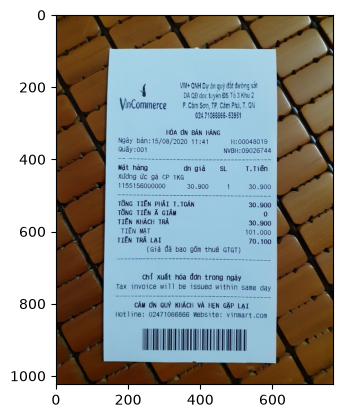

In [10]:
img = read_image(os.path.join(TRAIN_IMAGES_PATH, f"train_images/{df_train["img_id"][1]}"))
plt.imshow(img)

In [11]:
df_train["anno_polygons"] = df_train["anno_polygons"].apply(ast.literal_eval)

In [12]:
annotations = df_train.iloc[1]["anno_polygons"]

In [13]:
annotations

[{'category_id': 15,
  'segmentation': [[311.6, 226, 311.6, 264, 175, 264, 175, 226]],
  'area': 5206,
  'bbox': [175, 226, 137, 38],
  'width': 768,
  'height': 1024},
 {'category_id': 16,
  'segmentation': [[567.6, 180.5, 567.6, 207.1, 341.9, 207.1, 341.9, 180.5]],
  'area': 5876,
  'bbox': [342, 181, 226, 26],
  'width': 768,
  'height': 1024},
 {'category_id': 16,
  'segmentation': [[556.2, 211.8, 556.2, 232.7, 351.4, 232.7, 351.4, 211.8]],
  'area': 4305,
  'bbox': [351, 212, 205, 21],
  'width': 768,
  'height': 1024},
 {'category_id': 16,
  'segmentation': [[564.8, 240.3, 564.8, 265.9, 344.8, 265.9, 344.8, 240.3]],
  'area': 5720,
  'bbox': [345, 240, 220, 26],
  'width': 768,
  'height': 1024},
 {'category_id': 17,
  'segmentation': [[171.3,
    336,
    433.9,
    338.9,
    428.2,
    364.5,
    169.4,
    357.8,
    170.3,
    334.1]],
  'area': 6210,
  'bbox': [169, 334, 265, 31],
  'width': 768,
  'height': 1024},
 {'category_id': 18,
  'segmentation': [[390.3, 506.7, 390.

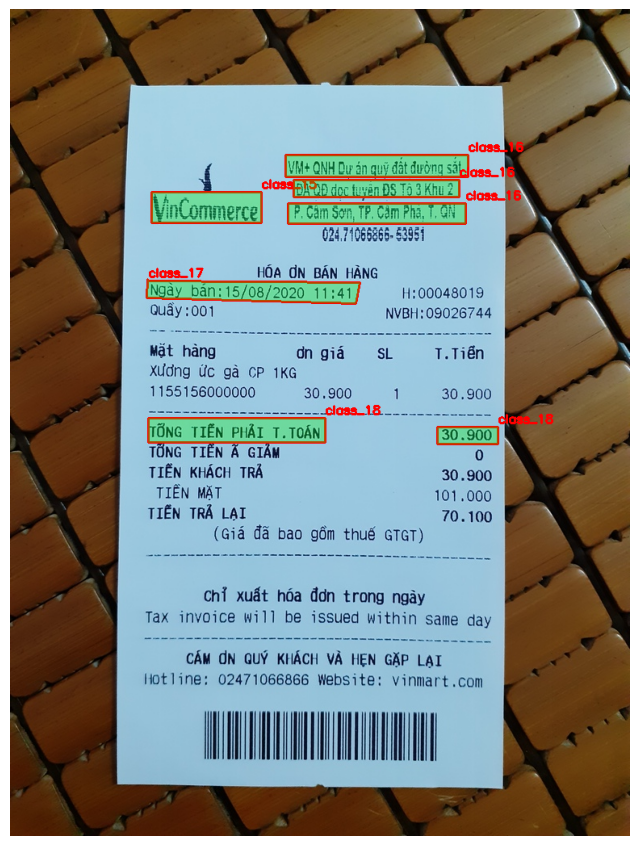

In [14]:
class_names = {
    15: "class_15",
    16: "class_16",
    17: "class_17",
    18: "class_18"
}

# Copy image
visualized = img.copy()

for ann in annotations:
    category_id = ann["category_id"]

    for segmentation in ann["segmentation"]:

        # Convert flat coordinates to (x, y)
        points = np.array(
            segmentation,
            dtype=np.float32
        ).reshape(-1, 2)

        points = points.astype(np.int32)

        # Draw polygon
        cv2.polylines(
            visualized,
            [points],
            isClosed=True,
            color=(255, 0, 0),
            thickness=2
        )

        # Fill polygon with transparency
        overlay = visualized.copy()

        cv2.fillPoly(
            overlay,
            [points],
            color=(0, 255, 0)
        )

        visualized = cv2.addWeighted(
            overlay, 0.3,
            visualized, 0.7,
            0
        )

        # Draw category label
        x, y = points[0]

        cv2.putText(
            visualized,
            class_names[category_id],
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(8, 12))
plt.imshow(visualized)
plt.axis("off")
plt.show()

In [15]:
print(f'anno_polygons: {df_train.iloc[1]["anno_polygons"]}')
print(f'anno_texts: {df_train.iloc[1]["anno_texts"]}')
print(f'anno_labels: {df_train.iloc[1]["anno_labels"]}')
print(f'anno_num: {df_train.iloc[1]["anno_num"]}')
print(f'anno_image_quality: {df_train.iloc[1]["anno_image_quality"]}')


anno_polygons: [{'category_id': 15, 'segmentation': [[311.6, 226, 311.6, 264, 175, 264, 175, 226]], 'area': 5206, 'bbox': [175, 226, 137, 38], 'width': 768, 'height': 1024}, {'category_id': 16, 'segmentation': [[567.6, 180.5, 567.6, 207.1, 341.9, 207.1, 341.9, 180.5]], 'area': 5876, 'bbox': [342, 181, 226, 26], 'width': 768, 'height': 1024}, {'category_id': 16, 'segmentation': [[556.2, 211.8, 556.2, 232.7, 351.4, 232.7, 351.4, 211.8]], 'area': 4305, 'bbox': [351, 212, 205, 21], 'width': 768, 'height': 1024}, {'category_id': 16, 'segmentation': [[564.8, 240.3, 564.8, 265.9, 344.8, 265.9, 344.8, 240.3]], 'area': 5720, 'bbox': [345, 240, 220, 26], 'width': 768, 'height': 1024}, {'category_id': 17, 'segmentation': [[171.3, 336, 433.9, 338.9, 428.2, 364.5, 169.4, 357.8, 170.3, 334.1]], 'area': 6210, 'bbox': [169, 334, 265, 31], 'width': 768, 'height': 1024}, {'category_id': 18, 'segmentation': [[390.3, 506.7, 390.3, 536.1, 171.3, 536.1, 171.3, 506.7]], 'area': 6351, 'bbox': [171, 507, 219, 

In [16]:
df_train.iloc[1]["img_id"]

'mcocr_public_145013fxcgs.jpg'

In [17]:
from paddleocr import PaddleOCR

In [ ]:
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    engine="paddle",
    enable_mkldnn=False,
    lang="vi"
)
result = ocr.predict(os.path.join(TRAIN_IMAGES_PATH, f"train_images/{df_train["img_id"][1]}"))
for res in result:
    res.print()
    res.save_to_img("output")
    res.save_to_json("output")

In [33]:
def to_reading_text(boxes_texts, y_tol=0.6):
    # boxes_texts: [(box(4x2), text), ...]
    items = []
    for box, text in boxes_texts:
        cy = box[:, 1].mean()
        h = box[:, 1].max() - box[:, 1].min()
        items.append([cy, box[:, 0].min(), h, text])
    items.sort(key=lambda t: t[0])

    lines, cur = [], [items[0]]
    for it in items[1:]:
        if abs(it[0] - np.mean([c[0] for c in cur])) < y_tol * np.mean([c[2] for c in cur]):
            cur.append(it)               # cùng hàng
        else:
            lines.append(cur); cur = [it]
    lines.append(cur)

    return "\n".join(" | ".join(t[3] for t in sorted(l, key=lambda t: t[1])) for l in lines)

import re
def clean(t):
    t = t.strip()
    # chỉ sửa khi cả chuỗi trông như số tiền, ví dụ "30.9O0" -> "30.900"
    if re.fullmatch(r"[\dOoIlSB.,]+", t) and re.search(r"\d", t):
        t = t.translate(str.maketrans("OoIlSB", "001158"))
    return t

In [80]:
boxes_texts = [(np.array(result[0]["rec_polys"][idx]), clean(result[0]["rec_texts"][idx])) for idx in range(len(result[0]["rec_scores"])) if res["rec_scores"][idx] > 0.3]


In [81]:
ocr_text = to_reading_text(boxes_texts)

In [82]:
ocr_text

'VM+ QNH D án quý đát duòng sát\nDA QD doc tuyên DS Tô 3 Khu 2\nVinCommerce | P. Câm Son, TP. Câm Phà, T. QN\n024.71066866-53951\nHÓA ÖN BÁN HÃNG\nNgày bán:15/08/2020 11:41 | H:00048019\nQuây:001 | NVBH:09026744\nMt hàng | dn giá | SL | T.Tiên\nxương c gà CP 1KG\n1155156000000 | 30.900 | 1 | 30.900\nTÖNG TIËN PHÃI T.TOÁN | 30.900\nTÖNG TIÊN Ã GIÃM | 0\nTIÊN KHÁCH TRÃ | 30.900\nTIÊN MT | 101.000\nTIÊN TRÃ LAI | 70.100\n(Giá đã bao gm thué GTGT)\nchǐ xuát hóa đđn trong ngày\nTax invoice will be issued within same day\nCÁM DN QUÝ KHÁCH VÀ HĘN GĂP LAI\nHotline: 02471066866 Website: vinmart.com'

In [86]:
'''
  Support set env for GROQ
'''
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")

In [93]:
Category = Literal["nguyên liệu", "đồ uống", "vận chuyển", "điện nước", "văn phòng phẩm", "khác"]

class Item(BaseModel):
    name: str = Field(description="Tên món hàng, đã sửa lỗi dấu nếu chắc chắn")
    qty: Optional[float] = Field(None, description="Số lượng")
    unit_price: Optional[int] = Field(None, description="Đơn giá, VND")
    amount: Optional[int] = Field(None, description="Thành tiền, VND")

class Invoice(BaseModel):
    seller: str = Field("", description="Tên nơi bán (cửa hàng, siêu thị)")
    category: Category = Field("khác", description="Danh mục chi tiêu")
    items: list[Item] = Field(default_factory=list, description="Các món hàng")
    total: Optional[int] = Field(None, description="Tổng tiền phải thanh toán, VND, số nguyên. null nếu không đọc rõ")
    date: Optional[dt.date] = Field(None, description="Ngày mua, định dạng YYYY-MM-DD. null nếu không đọc rõ")

    @field_validator("total", mode="before")
    @classmethod
    def parse_money(cls, v):
        if isinstance(v, str):                     # "30.900" -> 30900
            digits = re.sub(r"[^\d]", "", v)
            return int(digits) if digits else None
        return v

    @field_validator("seller", mode="before")
    @classmethod
    def strip_seller(cls, v):
        return v.strip() if isinstance(v, str) else ""

In [95]:
client = Groq()

In [96]:
from datetime import date

SYSTEM_PROMPT = """You extract structured data from OCR text of Vietnamese receipts and invoices \
(supermarkets, small shops, restaurants, utilities) for an expense ledger.

The OCR text is noisy:
- Vietnamese diacritics are often wrong or missing, and letters can be dropped entirely \
(e.g. "Mt hàng" = "Mặt hàng", "TÖNG TIËN PHÃI T.TOÁN" = "TỔNG TIỀN PHẢI T.TOÁN").
- Cells on the same row are joined with " | ". Rows are ordered top to bottom.

Rules:
1. NEVER invent or guess numbers. If an amount or date is not clearly present in the text, return null.
2. total = the final amount the customer must pay (labels like "TỔNG TIỀN PHẢI THANH TOÁN", \
"TỔNG CỘNG", "THÀNH TIỀN", "TOTAL"). It is NOT cash given ("TIỀN MẶT", "KHÁCH ĐƯA"), \
NOT change ("TIỀN TRẢ LẠI", "TIỀN THỪA"), and NOT the discount line.
3. Money is in VND, integers only. "." and "," are thousand separators: "30.900" -> 30900, "1,250,000" -> 1250000.
4. date: Vietnamese format is DD/MM/YYYY. Output as YYYY-MM-DD. Ignore time of day.
5. seller = the store or business name (e.g. "VinCommerce", "Bách Hóa Xanh"), not the address, \
not the invoice number, not the cashier.
6. items = only purchased goods/services. Exclude barcodes, product codes, invoice numbers, \
tax lines, discounts, totals and payment lines. A typical item row looks like \
"<name>" on one line, then "<code> | <unit_price> | <qty> | <amount>" on the next.
7. Fix item names and seller names only when you are confident (e.g. "xương c gà CP 1KG" -> "Xương ức gà CP 1KG"). \
If unsure, keep the text as it appears.
8. category must be exactly one of: nguyên liệu, đồ uống, vận chuyển, điện nước, văn phòng phẩm, khác. \
Use "khác" when unsure.
9. Use only the information in the OCR text. Do not use outside knowledge to fill in missing values."""


def build_user_prompt(ocr_text: str, today: date | None = None) -> str:
    today = today or date.today()
    return f"""Today's date is {today.isoformat()} (use it only to sanity-check the year; \
do not use it to fill in a missing date).

OCR text of the receipt:
<ocr>
{ocr_text}
</ocr>

Extract the invoice fields following the rules."""

In [99]:
response = client.chat.completions.create(
    model = "openai/gpt-oss-120b",
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(ocr_text)},
    ],
    seed = 2026,
    temperature = 0.0,
    max_tokens=8000,
    reasoning_effort = "low",
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "invoice_generation",
            "schema": Invoice.model_json_schema()
        }
    }
)

In [101]:
response

ChatCompletion(id='chatcmpl-2a48a65d-3473-423e-b946-9b110109d7dc', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "seller": "VinCommerce",\n  "date": "2020-08-15",\n  "total": 30900,\n  "category": "nguyên liệu",\n  "items": [\n    {\n      "name": "xương c gà CP 1KG",\n      "unit_price": 30900,\n      "qty": 1,\n      "amount": 30900\n    }\n  ]\n}', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning='We need total: final amount customer must pay. Look lines: "TIÊN KHÁCH TRÃ | 30.900" maybe amount paid? Actually "TIÊN KHÁCH TRÃ" = Tiền khách trả (customer gave) 30.900. Then "TIÊN TRÃ LAI | 70.100" change. So total should be 30.900? But also there is "TIÊN MT | 101.000" maybe tax? unclear. The total line "TÖNG TIËN PHÃI T.TOÁN | 30.900" that\'s total payable. So total = 30,900 VND.\n\nDate: "Ngày bán:15/08/2020 11:41" => 2020-08-15.\n\nSeller: "VinCommerce". Good.\n\nItems: one item: name "x